# import lib 

In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB 
from sklearn import metrics 
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve 
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc

In [5]:
df = pd.read_csv('titanic.csv') 
print("Dataset shape:", df.shape) 
print("\nColumnnames:") 
print(df.columns.tolist()) 
print("\nFirst 5 rows:") 
print(df.head()) 
print("\nDataset info:") 
print(df.info()) 

Dataset shape: (1309, 14)

Columnnames:
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']

First 5 rows:
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113

In [1]:
# from sklearn.datasets import fetch_openml

# # Download Titanic dataset
# titanic = fetch_openml(name="titanic", version=1, as_frame=True)

# # Save as CSV file
# titanic.frame.to_csv("titanic.csv", index=False)

# print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [2]:
# import os
# print(os.getcwd())


C:\Users\DSU-AI\Desktop\micro


In [7]:
df_processed = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']].copy() 
print("\nMissing values:") 
print(df_processed.isnull().sum()) 


Missing values:
pclass        0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
survived      0
dtype: int64


In [38]:
df_processed['age'].fillna(df_processed['age'].median(), inplace=True) 
df_processed['fare'].fillna(df_processed['fare'].median(), inplace=True) 
df_processed['embarked'].fillna(df_processed['embarked'].mode()[0], inplace=True) 
print("\nMissing values after handling:") 
print(df_processed.isnull().sum())


Missing values after handling:
pclass        0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      0
survived      0
dtype: int64


C:\Users\DSU-AI\AppData\Local\Temp\ipykernel_13096\924099959.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_processed['age'].fillna(df_processed['age'].median(), inplace=True)
C:\Users\DSU-AI\AppData\Local\Temp\ipykernel_13096\924099959.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thro

In [39]:
df_processed['age'] = df_processed['age'].fillna(df_processed['age'].median())
df_processed['fare'] = df_processed['fare'].fillna(df_processed['fare'].median())
df_processed['embarked'] = df_processed['embarked'].fillna(df_processed['embarked'].mode()[0])

print("\nMissing values after handling:")
print(df_processed.isnull().sum())


Missing values after handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


In [40]:
le_sex = LabelEncoder() 
le_embarked = LabelEncoder() 
df_processed['sex'] = le_sex.fit_transform(df_processed['sex']) 
df_processed['embarked'] = le_embarked.fit_transform(df_processed['embarked']) 
print("\nDataset after encoding:") 
print(df_processed.head())


Dataset after encoding:
   pclass  sex      age  sibsp  parch      fare  embarked  survived
0       1    0  29.0000      0      0  211.3375         2         1
1       1    1   0.9167      1      2  151.5500         2         1
2       1    0   2.0000      1      2  151.5500         2         0
3       1    1  30.0000      1      2  151.5500         2         0
4       1    0  25.0000      1      2  151.5500         2         0


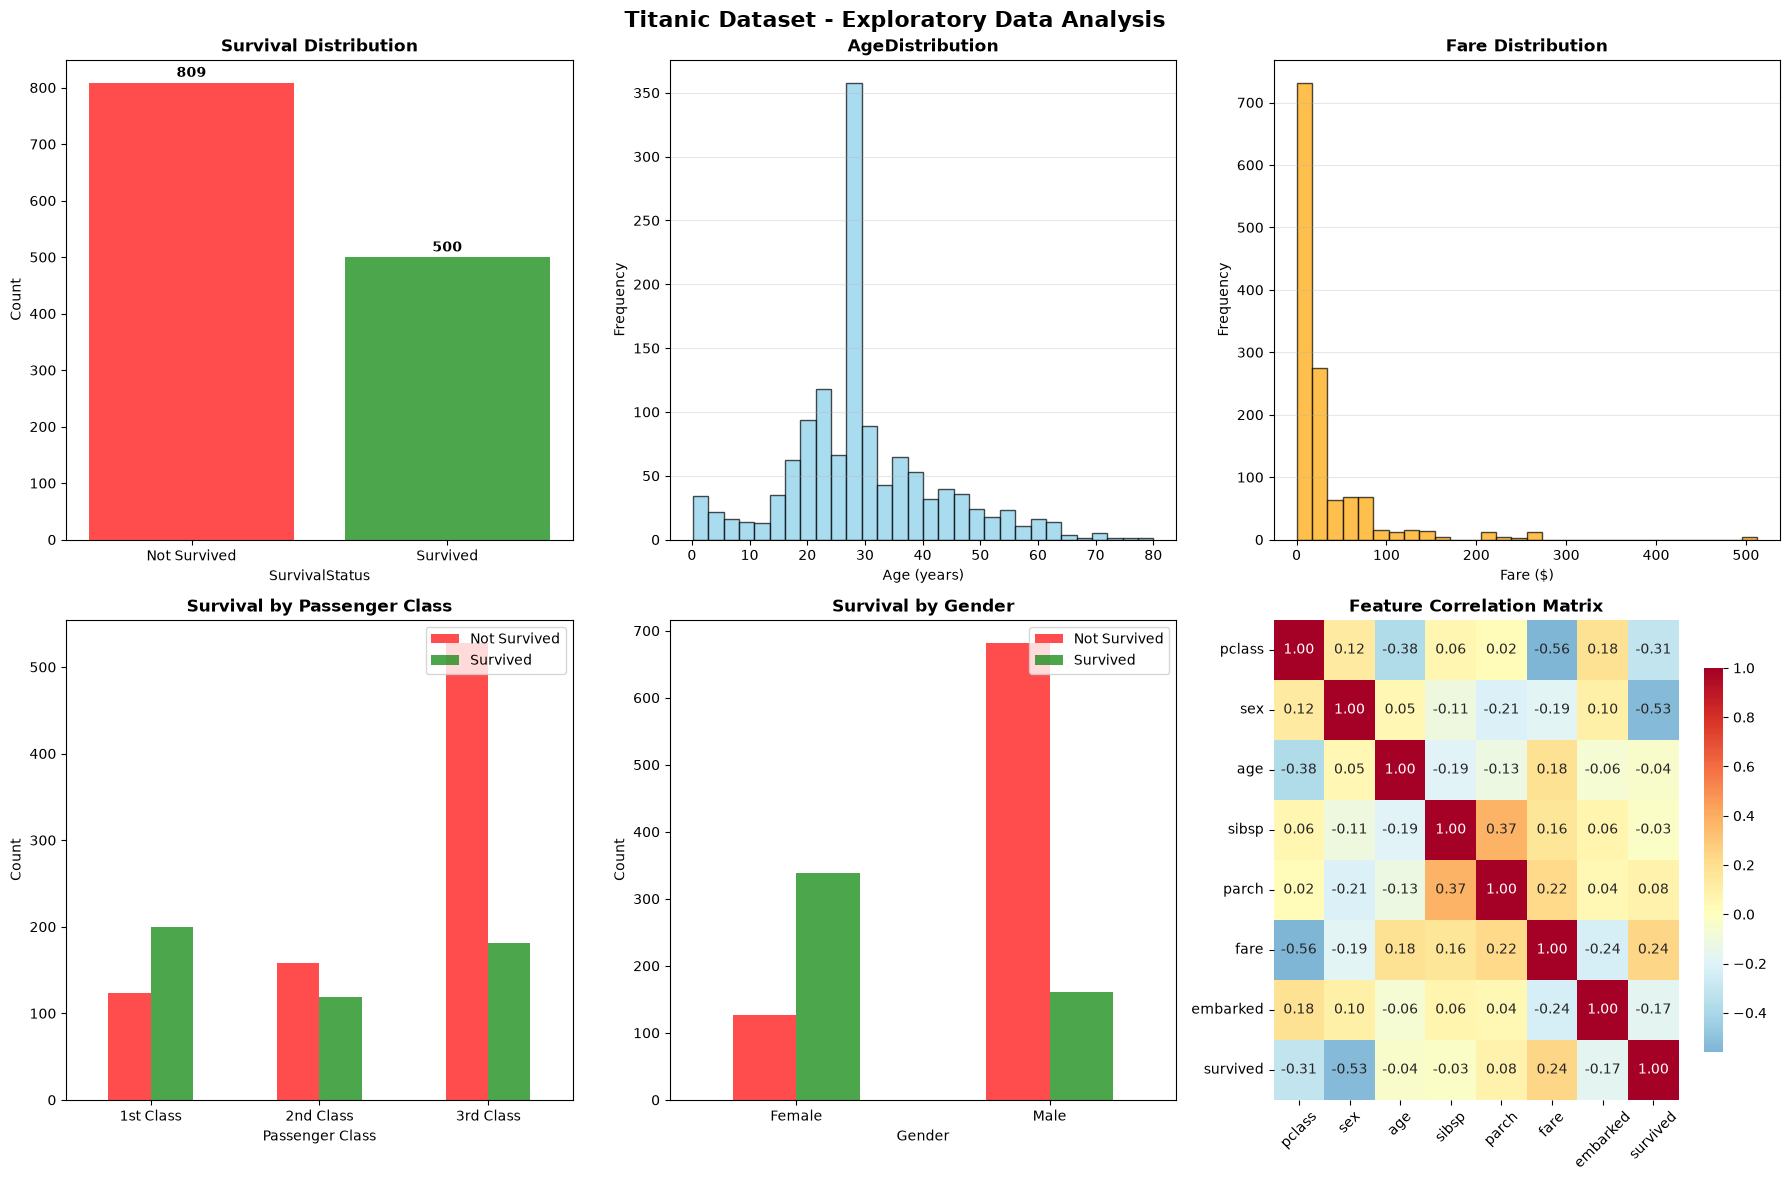

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12)) 
fig.suptitle('Titanic Dataset - Exploratory Data Analysis', fontsize=16, fontweight='bold')
axes[0, 0].bar(['Not Survived', 'Survived'], df_processed['survived'].value_counts(), color=['red', 'green'], alpha=0.7) 
axes[0, 0].set_title('Survival Distribution', fontsize=12, fontweight='bold') 
axes[0, 0].set_xlabel('SurvivalStatus',fontsize=10)
 
axes[0, 0].set_ylabel('Count', fontsize=10) 
 
for i, v in enumerate(df_processed['survived'].value_counts()): 
    axes[0, 0].text(i, v + 10, str(v), ha='center', fontweight='bold') 
 
# Age distribution 
axes[0, 1].hist(df_processed['age'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')  
axes[0, 1].set_title('AgeDistribution',fontsize=12, fontweight='bold') 
axes[0, 1].set_xlabel('Age (years)', fontsize=10) 
axes[0, 1].set_ylabel('Frequency', fontsize=10) 
axes[0, 1].grid(axis='y', alpha=0.3) 
 
# Fare distribution 
axes[0, 2].hist(df_processed['fare'], bins=30, alpha=0.7, color='orange', edgecolor='black') 
axes[0, 2].set_title('Fare Distribution',fontsize=12, fontweight='bold') 
axes[0, 2].set_xlabel('Fare ($)', fontsize=10) 
axes[0, 2].set_ylabel('Frequency', fontsize=10)  
axes[0, 2].grid(axis='y', alpha=0.3) 
 
# Survival by Class 
survival_by_class = pd.crosstab(df_processed['pclass'], df_processed['survived']) 
survival_by_class.plot(kind='bar', ax=axes[1, 0], color=['red', 'green'], alpha=0.7)  
axes[1, 0].set_title('Survival by Passenger Class', fontsize=12, fontweight='bold') 
axes[1, 0].set_xlabel('Passenger Class', fontsize=10) 
axes[1, 0].set_ylabel('Count', fontsize=10) 
axes[1, 0].legend(['Not Survived', 'Survived'], loc='upper right') 
axes[1, 0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0) 
 
# Survival by Sex 
survival_by_sex = pd.crosstab(df_processed['sex'], df_processed['survived']) 
survival_by_sex.plot(kind='bar', ax=axes[1, 1], color=['red', 'green'], alpha=0.7)  
axes[1, 1].set_title('Survival by Gender', fontsize=12, fontweight='bold') 
axes[1, 1].set_xlabel('Gender', fontsize=10) 
axes[1, 1].set_ylabel('Count', fontsize=10) 
axes[1, 1].legend(['Not Survived', 'Survived'], loc='upper right')  
axes[1, 1].set_xticklabels(['Female', 'Male'], rotation=0) 
 
# Correlation matrix 
correlation_matrix = df_processed.corr() 
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f', ax=axes[1, 2], cbar_kws={'shrink': 0.8}) 
axes[1, 2].set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold') 
axes[1, 2].tick_params(axis='x', rotation=45) 
axes[1, 2].tick_params(axis='y', rotation=0) 
plt.tight_layout()  
plt.show()

In [42]:
# Split features and target 
X = df_processed.drop('survived', axis=1)
y = df_processed['survived'] 
print(f"\nFeatures: {list(X.columns)}") 
print(f"Target distribution:\n{y.value_counts()}")



Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Target distribution:
survived
0    809
1    500
Name: count, dtype: int64


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) 
print(f"\nTraining set size: {X_train.shape[0]}")  
print(f"Testing set size:{X_test.shape[0]}") 


Training set size: 981
Testing set size:328


In [44]:
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test) 

In [45]:
# Create and train Naive Bayes classifier 
classifier = GaussianNB() 
classifier.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[625.,356.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.64,0.36]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 7)","[[ 0.23, 0.39, 0.02,...,-0.05,-0.19, 0.14], [-0.41,-0.69,-0.03,..., 0.1 , 0.34,-0.24]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 7)","[[0.79,0.61,0.87,...,1.13,0.4 ,0.8 ], [1.1 ,0.94,1.24,...,0.76,1.86,1.26]]"


In [46]:
y_pred = classifier.predict(X_test_scaled) 
y_pred_proba = classifier.predict_proba(X_test_scaled)[:, 1] 

In [47]:
print("\nPredictions vs Actual (first 10):") 
print("Predicted | Actual | Probability") 
print("-" * 32) 
for i in range(min(10, len(y_pred))): 
 print(f" {y_pred[i]} | {y_test.iloc[i]} | {y_pred_proba[i]:.3f}") 


Predictions vs Actual (first 10):
Predicted | Actual | Probability
--------------------------------
 0 | 0 | 0.034
 0 | 1 | 0.176
 0 | 0 | 0.033
 0 | 0 | 0.033
 0 | 0 | 0.051
 0 | 1 | 0.226
 0 | 0 | 0.034
 0 | 1 | 0.063
 0 | 0 | 0.052
 1 | 1 | 0.905


In [48]:
 
# Calculate accuracy 
accuracy = accuracy_score(y_test, y_pred) 
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)") 


Accuracy: 0.7591 (75.91%)


In [49]:
print(f'\nClassification Report:') 
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived'])) 
 
# Confusion matrix with proper formatting 
cf_matrix = confusion_matrix(y_test, y_pred) 
print(f"\nConfusion Matrix:") 
print(cf_matrix) 


Classification Report:
              precision    recall  f1-score   support

Not Survived       0.75      0.85      0.80       184
    Survived       0.77      0.65      0.70       144

    accuracy                           0.76       328
   macro avg       0.76      0.75      0.75       328
weighted avg       0.76      0.76      0.76       328


Confusion Matrix:
[[156  28]
 [ 51  93]]


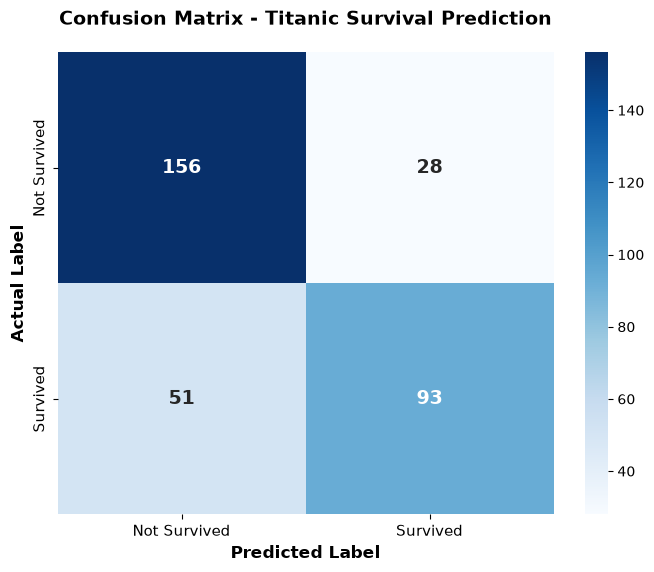

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

In [50]:
plt.figure(figsize=(8, 6)) 
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=True, 
xticklabels=['Not Survived', 'Survived'], 
yticklabels=['Not Survived', 'Survived'], 
annot_kws={'size': 14, 'weight': 'bold'}) 
plt.title('Confusion Matrix - Titanic Survival Prediction', fontsize=14, fontweight='bold', pad=20) 
plt.ylabel('Actual Label', fontsize=12, fontweight='bold') 
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')  
plt.tick_params(axis='both', which='major', labelsize=11) 
plt.show() 
 
# Plot Precision-Recall Curve and ROC Curve with proper formatting 
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba) 
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba) 
roc_auc = auc(fpr, tpr) 
plt.figure(figsize=(14, 6))

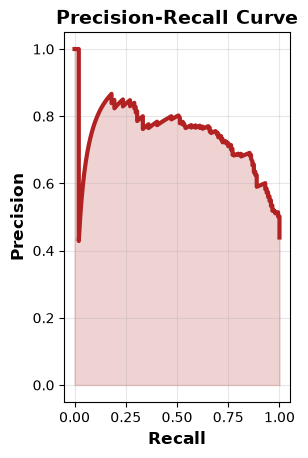

In [51]:
 # Precision-Recall Curve 
plt.subplot(1, 2, 1) 
plt.plot(recall, precision, label='Naive Bayes', color='firebrick', linewidth=3) 
plt.fill_between(recall, precision, alpha=0.2, color='firebrick') 
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')  
plt.xlabel('Recall', fontsize=12, fontweight='bold') 
plt.ylabel('Precision', fontsize=12, fontweight='bold') 
plt.grid(True, alpha=0.3) 
plt.tick_params(axis='both', which='major', labelsize=10) 

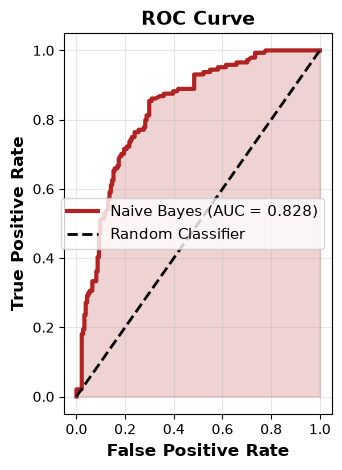

In [54]:
# ROC Curve 
plt.subplot(1, 2, 2) 
plt.plot(fpr, tpr, label=f'Naive Bayes (AUC = {roc_auc:.3f})', color='firebrick', linewidth=3)  
plt.fill_between(fpr, tpr, alpha=0.2, color='firebrick') 
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2) 
plt.title('ROC Curve', fontsize=14, fontweight='bold') 
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')  
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')  
plt.legend(fontsize=11) 
plt.grid(True, alpha=0.3) 
plt.tick_params(axis='both', which='major', labelsize=10) 
plt.tight_layout()  
 
plt.show()

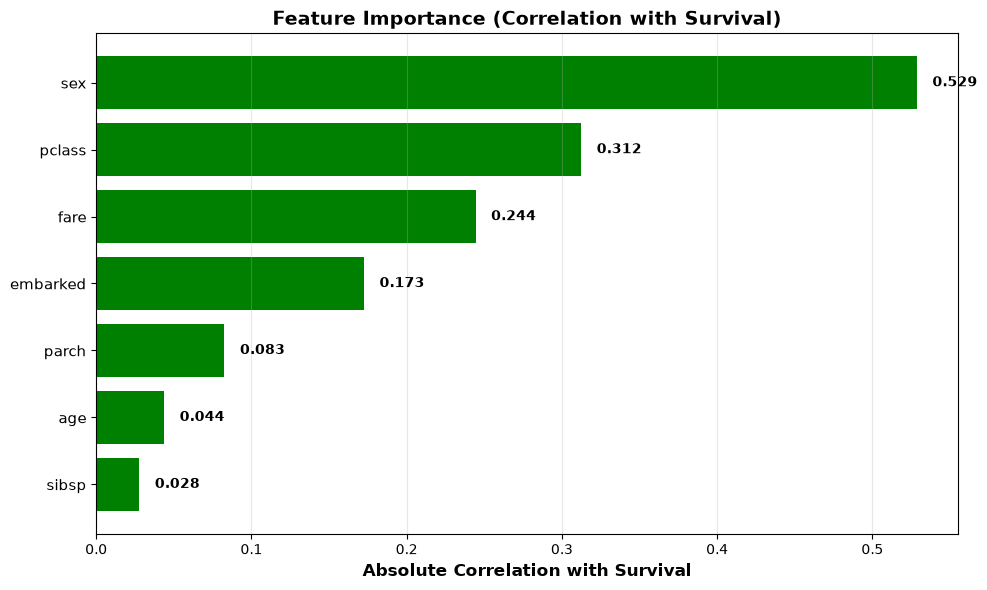

In [58]:
# Feature importance visualization
feature_importance = abs(
    correlation_matrix['survived'].drop('survived')
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    range(len(feature_importance)),
    feature_importance.values,
    color='green'
)

plt.yticks(
    range(len(feature_importance)),
    feature_importance.index,
    fontsize=11
)

plt.xlabel('Absolute Correlation with Survival', fontsize=12, fontweight='bold')
plt.title('Feature Importance (Correlation with Survival)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, feature_importance.values)):
    plt.text(value + 0.01, i, f'{value:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [59]:
 
# Calculate additional metrics 
precision_score = metrics.precision_score(y_test, y_pred)  
recall_score = metrics.recall_score(y_test, y_pred) 
f1 = f1_score(y_test, y_pred) 
 
print("\n" + "="*50) 
print("PERFORMANCE SUMMARY:") 
print("="*50) 
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")  
print(f"Precision: {precision_score:.4f}") 
print(f"Recall: {recall_score:.4f}") 
print(f"F1-Score: {f1:.4f}") 
print(f"AUC-ROC: {roc_auc:.4f}") 
 
print(f"\nFeature Importance (Correlation with Survival):") 
for feature, importance in feature_importance.sort_values(ascending=False).items():   
    print(f"• {feature}: {importance:.3f}") 


PERFORMANCE SUMMARY:
Accuracy: 0.7591 (75.91%)
Precision: 0.7686
Recall: 0.6458
F1-Score: 0.7019
AUC-ROC: 0.8282

Feature Importance (Correlation with Survival):
• sex: 0.529
• pclass: 0.312
• fare: 0.244
• embarked: 0.173
• parch: 0.083
• age: 0.044
• sibsp: 0.028
